# Tema 2 - Tokenizers & Vision Preprocessing
First of all, we need to setup and install the dependancies we will need for this project.

In [1]:
%pip install -q qwen-vl-utils


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 48.3 MB/s eta 0:00:00


In [ ]:
%pip install -q transformers accelerate torch pillow requests tokenizers matplotlib

---
### Tema 2A / Task 2A - Tokenizers
> Antrenati un tokenizer folosind HF *tokenizers* library.
>
> ---
> Train a tokenizer using HuggingFace's *tokenizers* library

In [ ]:
###############################################################################################################
# Step 1 -> Download a small plain-text corpus (no 'datasets'/pyarrow needed -> avoids the Windows pyarrow DLL error)
import requests

corpus_url = "https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/train.txt"

response = requests.get(corpus_url)
response.raise_for_status()
lines = [line.strip() for line in response.text.splitlines() if line.strip()]

with open("corpus.txt", "w", encoding="utf-8") as f:
    count = 0
    for line in lines:
        f.write(line + "\n")
        count += 1
        if count >= 5000:  # We keep it small for performance
            break

print(f"Wrote {count} lines to corpus.txt")


Wrote 5000 lines to corpus.txt


In [ ]:
###############################################################################################################
# Step 2 -> Train a BPE tokenizer from scratch on the downloaded corpus
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=10000,
    special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"],
)

tokenizer.train(files=["corpus.txt"], trainer=trainer)
tokenizer.save("custom-bpe-tokenizer.json")

print("Vocabulary size:", tokenizer.get_vocab_size())


Vocabulary size: 10000


In [ ]:
###############################################################################################################
# Step 3 -> Try the trained tokenizer on some example sentences
sentences = [
    "Tokenization is the first step of any NLP pipeline.",
    "Transformers use subword tokenizers like BPE or WordPiece.",
    "Unbelievably, antidisestablishmentarianism is a very long word.",
]

for sentence in sentences:
    encoding = tokenizer.encode(sentence)
    print("=" * 80)
    print("TEXT:  ", sentence)
    print("TOKENS:", encoding.tokens)
    print("IDS:   ", encoding.ids)


TEXT:   Tokenization is the first step of any NLP pipeline.
TOKENS: ['T', 'ok', 'en', 'ization', 'is', 'the', 'first', 'step', 'of', 'any', 'NL', 'P', 'p', 'ipel', 'ine', '.']
IDS:    [56, 431, 184, 2453, 192, 175, 401, 3151, 188, 567, 3601, 52, 81, 4133, 341, 18]
TEXT:   Transformers use subword tokenizers like BPE or WordPiece.
TOKENS: ['Tran', 's', 'form', 'ers', 'use', 'sub', 'word', 'to', 'ken', 'iz', 'ers', 'like', 'BP', 'E', 'or', 'Word', 'P', 'ie', 'ce', '.']
IDS:    [4201, 84, 394, 253, 627, 625, 1677, 196, 2278, 519, 253, 756, 7899, 41, 183, 9866, 52, 654, 232, 18]
TEXT:   Unbelievably, antidisestablishmentarianism is a very long word.
TOKENS: ['Un', 'believ', 'ably', ',', 'ant', 'id', 'is', 'establishment', 'arian', 'ism', 'is', 'a', 'very', 'long', 'word', '.']
IDS:    [439, 3513, 1823, 16, 290, 239, 192, 4805, 2605, 840, 192, 66, 894, 656, 1677, 18]


---
### Tema 2B / Task 2B - Tokenizers
> Incarcati un VLM mic
>
> Redimensionati si incarcati o imagine, cu diverse rezolutii, crop, etc
>
> Observati cum se modifica rezultatul in functie de aceste transformari
>
> ---
> Load a small VLM
>
> Resize and Load an image using different resolutions, crops, etc
>
> Observe how the results change depending on these transformations

In [2]:
###############################################################################################################
# Step 0 -> Loading 'Qwen2-VL-2B-Instruct' VLM -> https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct
import torch
import transformers
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

VLM_MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"

dtype = torch.float16 if torch.cuda.is_available() else torch.float32

vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
    VLM_MODEL_NAME,
    dtype=dtype,
)

vlm_processor = AutoProcessor.from_pretrained(VLM_MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vlm_model = vlm_model.to(device)
vlm_model.eval()

print("Transformers:", transformers.__version__)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")
print("Model loaded!")



config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Transformers: 5.16.1
Device: CUDA
Model loaded!


In [3]:
###
#Step 0.5 -> Helper Function to process the image and text input for the VLM
from qwen_vl_utils import process_vision_info

def ask_vlm(image, question, max_new_tokens=256):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]

    text = vlm_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = vlm_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(vlm_model.device)

    generated_ids = vlm_model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = vlm_processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text[0]


Image size: (837, 627)


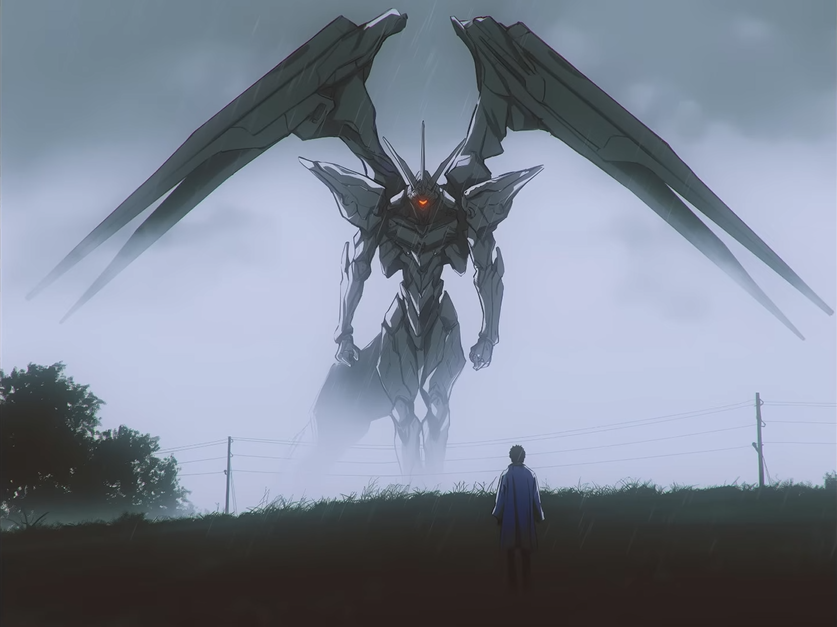

In [4]:
###############################################################################################################
# Step 1 -> Load a local base image
from PIL import Image
from IPython.display import display

def load_image(image_path="./AnImage.png"):
    image = Image.open(image_path).convert("RGB")
    return image

base_image = load_image("./AnImage.png")

print("Image size:", base_image.size)
display(base_image)


Resolution: (837, 627)


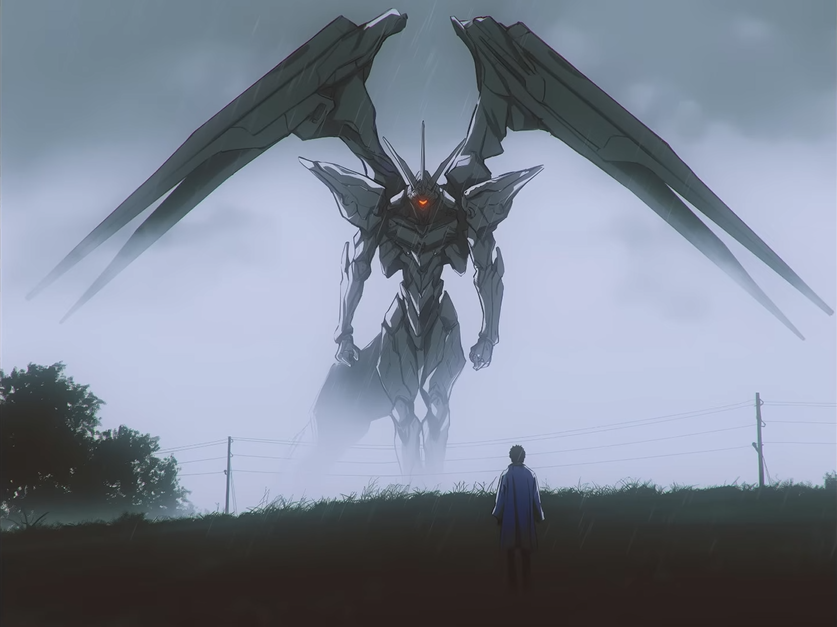

The image depicts a dramatic scene featuring a large, mechanical figure with wings and a glowing red eye, standing in a misty, overcast landscape. The figure appears to be a futuristic, possibly robotic entity with a sleek, metallic design. The figure is positioned on the left side of the image, with its wings spread wide and its body facing the viewer.

In the foreground, there is a person standing on a grassy field, facing the mechanical figure. The person is dressed in a long, flowing coat, and their posture suggests a sense of awe or contemplation. The field is surrounded by a fence, and in the background, there are trees and a cloudy sky, adding to the somber and intense atmosphere of the scene.

The overall mood of the image is one of suspense and wonder, as the mechanical figure looms over the person, creating a sense of impending danger or revelation.
Resolution: (150, 112)


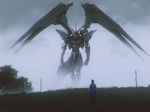

The image depicts a large, fantastical creature with wings that resemble those of a dragon. The creature is positioned in the center of the image, dominating the scene. It has a dark, almost metallic appearance with a glowing, fiery hue around its wings and body. The wings are spread wide, and the creature appears to be in a state of flight or motion.

In the foreground, there is a person standing on the ground. The individual is dressed in a dark outfit, and they are facing away from the viewer, looking towards the creature. The person's posture suggests they are either observing the creature or preparing to interact with it.

The background is a misty, overcast sky, which adds a sense of mystery and drama to the scene. The ground appears to be a flat, open field, and there are no other significant objects or elements in the image.

Overall, the image conveys a sense of awe and wonder, with the large, powerful creature and the solitary figure creating a striking contrast.
Resolution: 

The image depicts a scene with a large, dark, and somewhat ominous figure flying in the sky. The figure appears to be a bird, possibly a dragon or a similar mythical creature, given its large size and the way it is flying. The bird is in mid-flight, with its wings spread wide and its body angled slightly upward, suggesting it is in the process of taking off or landing. The background is blurred, making it difficult to discern any specific details, but it appears to be a natural environment with some trees and foliage visible. The overall atmosphere of the image is tense and foreboding.
Resolution: (627, 627)


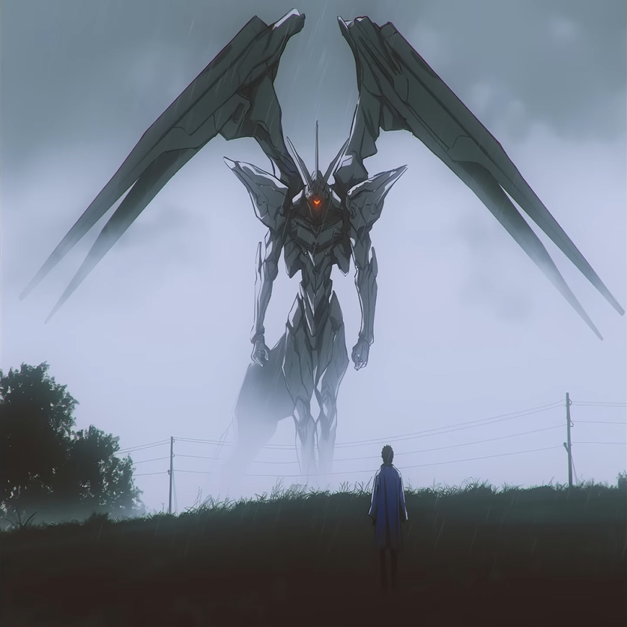

The image depicts a futuristic scene featuring a large, mechanical figure with intricate designs and glowing eyes. The figure has a humanoid form with long, slender arms and legs, and its wings are outstretched, suggesting it is in a defensive or aggressive posture. The wings are composed of a metallic material with a dark, almost metallic sheen. The figure's body is covered in a metallic texture, and it has a glowing red eye in the center of its forehead, which adds to its menacing appearance.

In the foreground, there is a person standing on a grassy field, facing the mechanical figure. The person is dressed in a long, flowing coat, and they appear to be observing the mechanical being. The background is a cloudy sky with a hint of rain, and there are power lines and trees visible in the distance, indicating an industrial or urban setting. The overall atmosphere of the image is dramatic and intense, with a sense of impending conflict or confrontation.
Resolution: (112, 112)


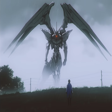

The image depicts a large, fantastical creature with wings that appear to be made of metal or some other metallic material. The creature has a dark, almost black coloration and is set against a backdrop that suggests a misty or foggy environment. The creature's wings are spread wide, and it seems to be in a dynamic pose, as if it is either flying or preparing to take flight.

In the foreground, there is a person standing on a platform or elevated surface. The person is dressed in a dark, possibly black, outfit, and appears to be looking up at the creature with a sense of awe or curiosity. The overall scene has a dramatic and somewhat ominous atmosphere, enhanced by the misty background and the dark, metallic appearance of the creature.
Resolution: (16, 16)


The image depicts a scene of a plane flying in the sky. The plane is captured from a low angle, giving a sense of its size and the vastness of the sky. The plane is in mid-flight, with its wings spread wide and its body angled slightly upward. The background is a clear blue sky with no visible clouds, suggesting good weather conditions. The plane appears to be a commercial jet, identifiable by its size and the number of windows visible on its fuselage. The overall composition of the image emphasizes the plane's motion and the vastness of the sky it is flying through.
Resolution: (124, 516)


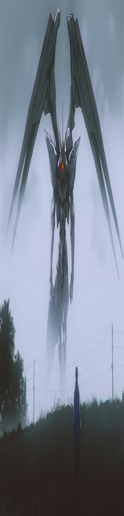

The image depicts a large, majestic bird-like creature with wings that span across the sky. The creature has a sleek, streamlined body and is adorned with intricate patterns and designs. It appears to be in flight, soaring high above a landscape that includes a field and a few trees. The bird's wings are spread wide, and its body is elongated, giving it a powerful and majestic appearance.

In the foreground, there is a person standing on the ground, observing the bird. The person is dressed in casual attire, wearing a jacket and pants, and appears to be looking up at the bird with a sense of awe or admiration. The background is slightly blurred, emphasizing the bird and the person in the foreground.

The overall scene conveys a sense of wonder and the beauty of nature, with the bird as a symbol of power and grace. The use of color and lighting adds to the dramatic effect, highlighting the bird's majestic form against the more muted tones of the landscape.


In [ ]:
###############################################################################################################
# Step 2 -> Resize the image to different resolutions and compare VLM answers
resolutions = [(837, 627), (150,112), (21,16), (627, 627), (112, 112),(16, 16), (124, 516)]

for size in resolutions:
    resized = base_image.resize(size)

    print("=" * 80)
    print(f"Resolution: {size}")

    display(resized)

    answer = ask_vlm(
        resized,
        "Describe this image and list the main objects you see.",
    )
    print(answer)


Crop: full_image, size: (837, 627)


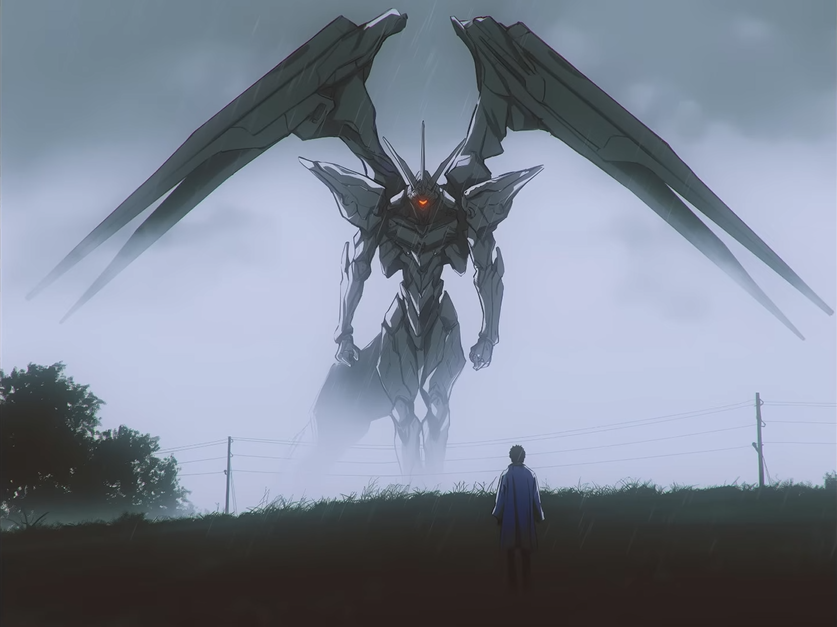

The image depicts a dramatic scene featuring a large, mechanical figure with wings and a glowing red eye, standing in a misty, overcast landscape. The figure appears to be a futuristic, possibly robotic entity with a sleek, metallic design. The figure is positioned on the left side of the image, with its wings spread wide and its body facing the viewer.

In the foreground, there is a person standing on a grassy field, facing the mechanical figure. The person is dressed in a long, flowing coat, and their posture suggests a sense of awe or contemplation. The field is surrounded by a fence, and in the background, there are trees and a cloudy sky, adding to the somber and intense atmosphere of the scene.

The overall mood of the image is one of suspense and wonder, as the mechanical figure looms over the person, creating a sense of impending danger or revelation.
Crop: crop_1, size: (804, 457)


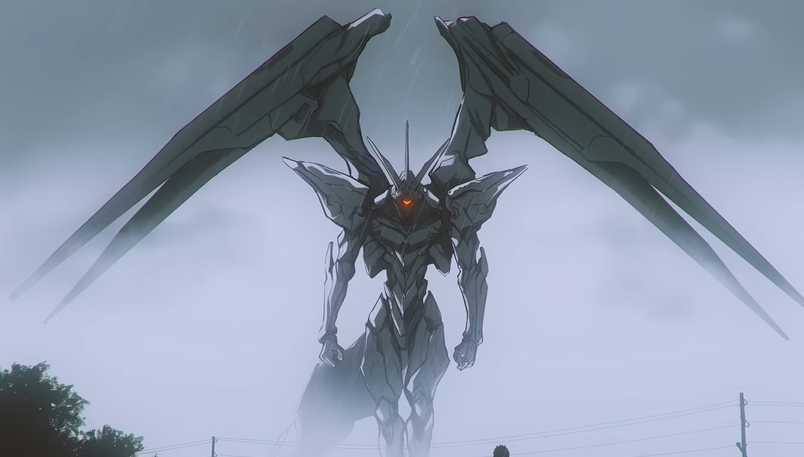

The image depicts a large, futuristic robot with a sleek, metallic design. The robot has two large, outstretched wings that resemble those of a dragon, giving it a menacing and powerful appearance. The wings are dark gray and have a sharp, pointed tip. The robot's body is also metallic, with a complex structure that includes multiple segments and a central core. The robot's head is small and pointed, with a glowing red eye that emits a bright light. The background is a cloudy sky with a hint of rain, adding to the dramatic and intense atmosphere of the scene. The robot is standing on what appears to be a flat surface, possibly a field or a platform.
Crop: crop_2, size: (100, 201)


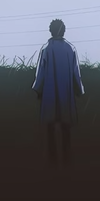

The image depicts a person standing in a field. The individual is wearing a long, dark-colored coat that covers most of their body. The coat appears to be made of a heavy fabric, possibly wool or a similar material, and it has a slightly puffed design. The person is standing with their back to the camera, facing a line of tall, green grass. The background consists of a clear sky and some distant trees or bushes. The overall scene suggests a serene, outdoor setting.
Crop: crop_3, size: (318, 270)


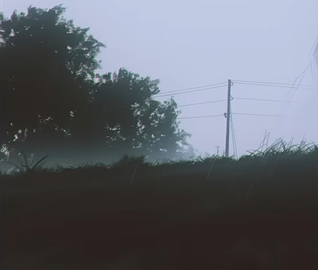

The image depicts a rural or semi-rural scene during a rainy day. The main objects visible in the image include:

1. **Trees**: There are several trees in the background, with their branches and leaves visible through the mist or fog. The trees appear to be deciduous, as they have leaves that are not fully developed.

2. **Power Lines**: There are power lines running across the image, indicating the presence of an electrical infrastructure. These lines are tall and straight, running horizontally across the scene.

3. **Hillside**: The foreground of the image shows a hillside covered with grass and possibly some low vegetation. The hillside is slightly obscured by the mist or fog.

4. **Fog or Mist**: The sky is filled with a dense layer of fog or mist, which makes it difficult to see beyond a certain distance. The visibility is low, and the details of the trees and power lines are somewhat obscured.

5. **Lighting**: The lighting in the image is dim, likely due to the fog or mist, whic

In [ ]:
###############################################################################################################
# Step 3 -> Crop the image and compare VLM answers
width, height = base_image.size

crops = {
    "full_image": base_image,

    "crop_1": base_image.crop(
        (
            int(0.02 * width),
            int(0.00 * height),
            int(0.98 * width),
            int(0.73 * height),
        )
    ),

    "crop_2": base_image.crop(
        (
            int(0.55 * width),
            int(0.68 * height),
            int(0.67 * width),
            int(1.00 * height),
        )
    ),
    "crop_3": base_image.crop(
        (
            int(0.00 * width),
            int(0.57 * height),
            int(0.38 * width),
            int(1.00 * height),
        )
    ),
}

for name, cropped in crops.items():
    print("=" * 80)
    print(f"Crop: {name}, size: {cropped.size}")

    display(cropped)

    answer = ask_vlm(
        cropped,
        "Describe this image and list the main objects you see.",
    )
    print(answer)


---
---

# Bonus
In this part we will try to interpret the model. For this, we will need Attribution. Attribution is essentialy asking the model "What region/token contributed to the generated answer?".

We will first try using Integrated Gradient methods, then the Occlusion method.

## Integrated Gradient Method (IG)
Integrated Gradient is a method in which we start from a baseline image and work towards the original image, along the way we watch which part/regions/pixels helped the model.

*Hint: if completness value is >10% the result is considered not trust-worthy*


Model: Qwen/Qwen2-VL-2B-Instruct | Transformers: 5.16.1
Grid: 44x60 patches -> 22x30 tokens | patch 14x14 | merge 2x2


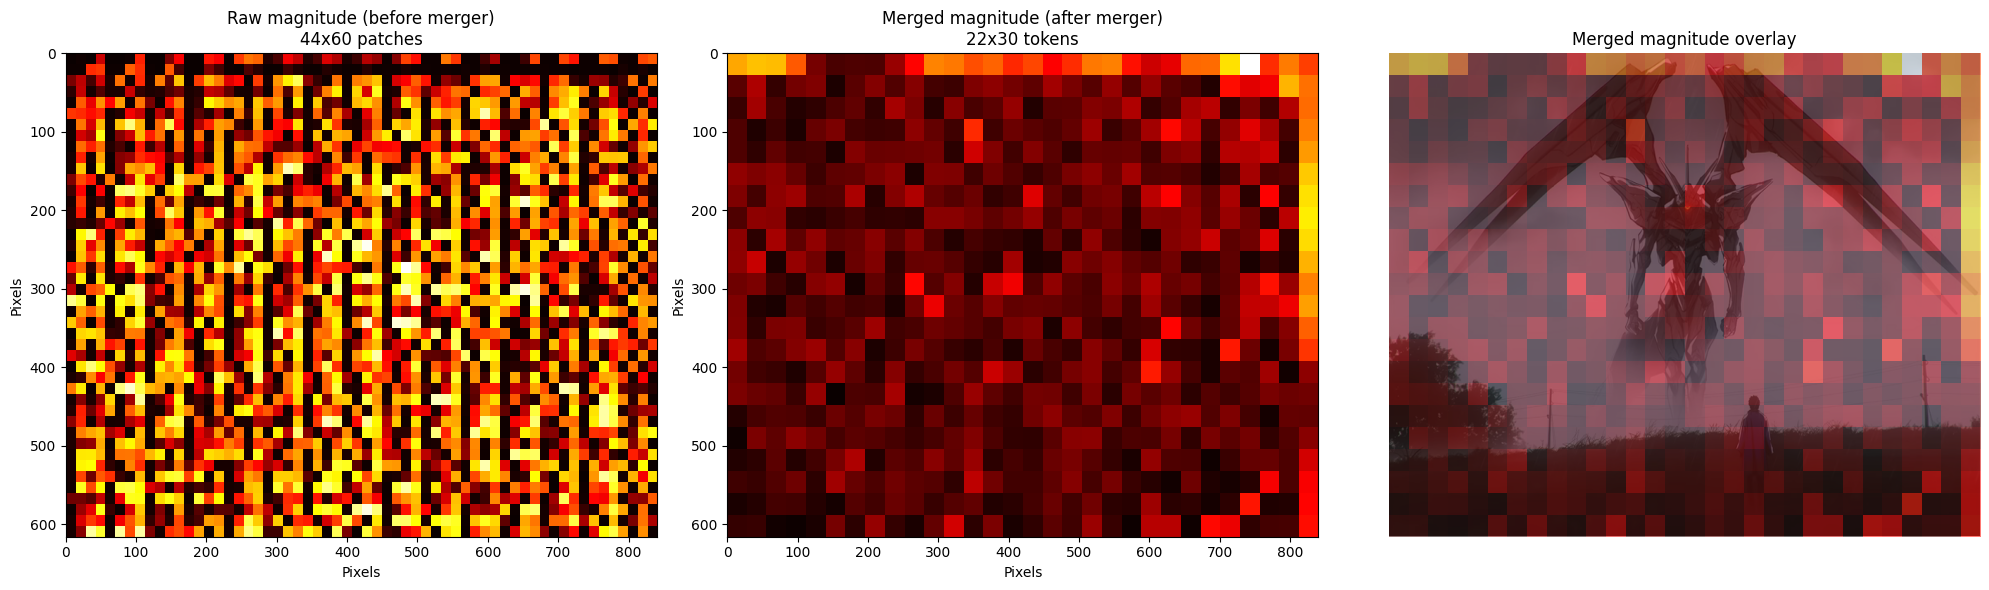

Prompt tokens: 692 | Answer tokens: 181
Answer: The image depicts a dramatic scene featuring a large, mechanical figure with wings and a glowing red eye, standing in a misty, overcast landscape. The figure appears to be a futuristic, possibly robotic entity with a sleek, metallic design. The figure is positioned on the left side of the image, with its wings spread wide and its body facing the viewer.

In the foreground, there is a person standing on a grassy field, facing the mechanical figure. The person is dressed in a long, flowing coat, and their posture suggests a sense of awe or contemplation. The field is surrounded by a fence, and in the background, there are trees and a cloudy sky, adding to the somber and intense atmosphere of the scene.

The overall mood of the image is one of suspense and wonder, as the mechanical figure looms over the person, creating a sense of impending danger or revelation.

Input score: -95.4005 | Baseline score: -117.2458 | True delta: 21.8452
step   

/tmp/ipykernel_676/2990351783.py:175: RuntimeWarning: invalid value encountered in power
  signed_rgba[..., 3] = 0.85 * (attr_signed_up ** 0.7)


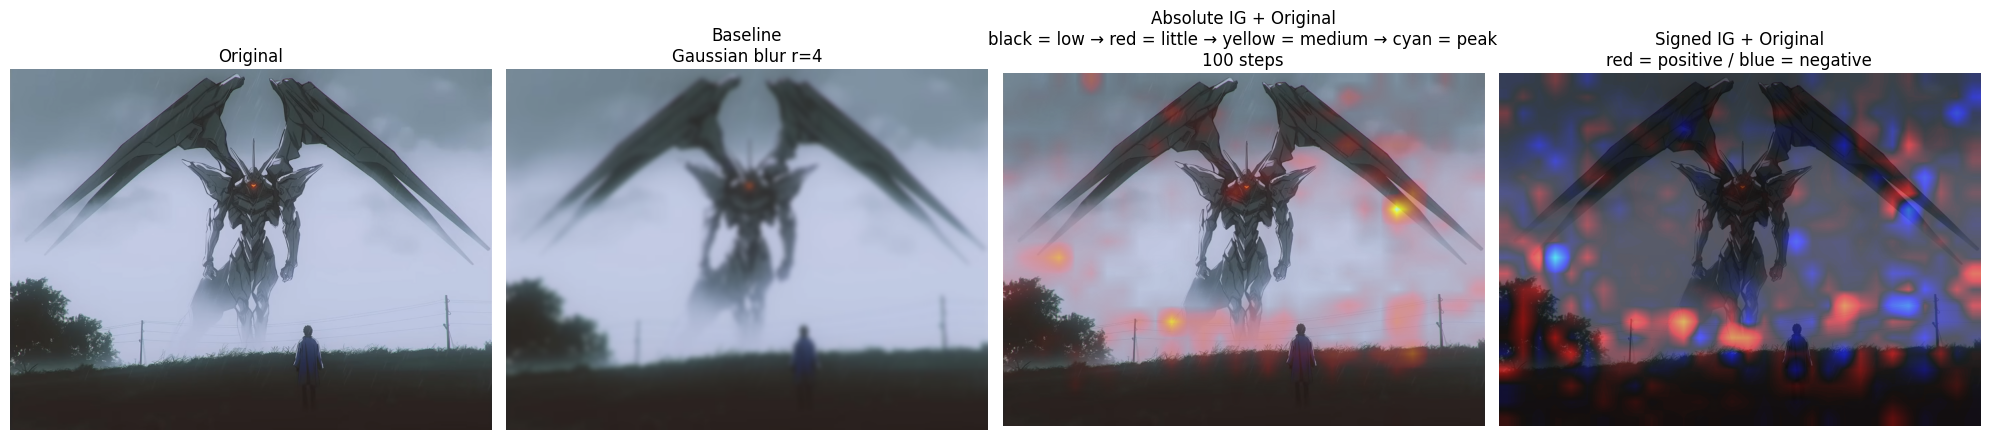


Steps: 100 | Input: -95.4005 | Baseline: -117.2458 | Delta: 21.8452 | IG sum: 20.1413 | Error: 7.80%

=== Generated answer ===
The image depicts a dramatic scene featuring a large, mechanical figure with wings and a glowing red eye, standing in a misty, overcast landscape. The figure appears to be a futuristic, possibly robotic entity with a sleek, metallic design. The figure is positioned on the left side of the image, with its wings spread wide and its body facing the viewer.

In the foreground, there is a person standing on a grassy field, facing the mechanical figure. The person is dressed in a long, flowing coat, and their posture suggests a sense of awe or contemplation. The field is surrounded by a fence, and in the background, there are trees and a cloudy sky, adding to the somber and intense atmosphere of the scene.

The overall mood of the image is one of suspense and wonder, as the mechanical figure looms over the person, creating a sense of impending danger or revelation.


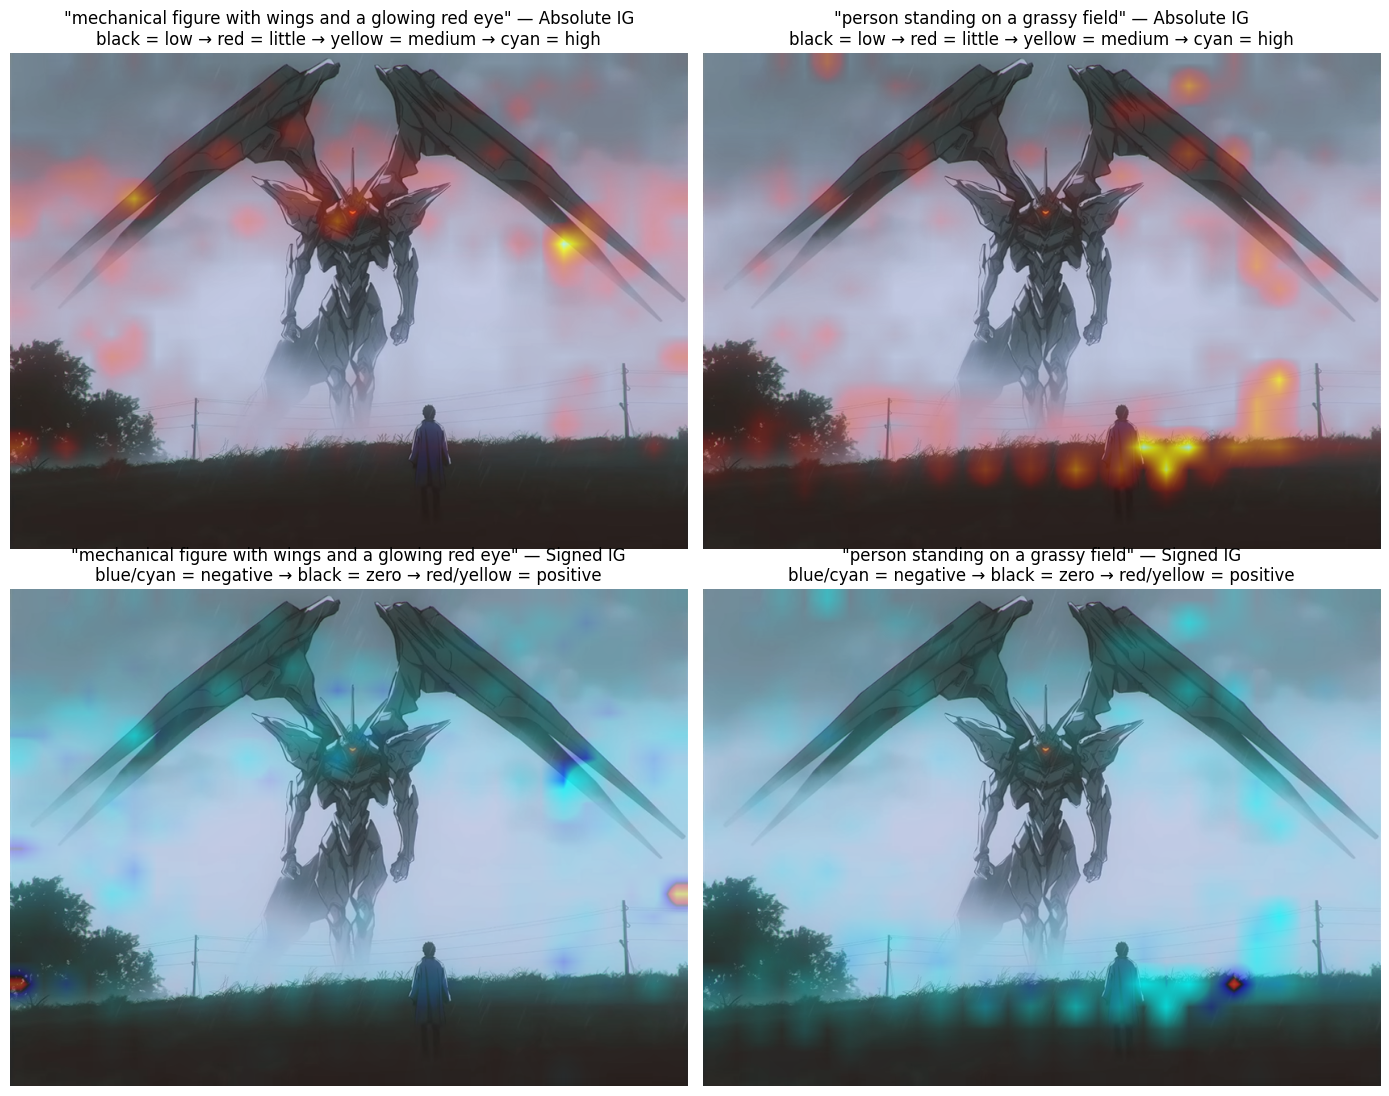

In [7]:
# Step BONUS -> Qwen2-VL visual feature magnitude + vision self-attention maps
import torch, torch.nn.functional as F, numpy as np, matplotlib.pyplot as plt, transformers
from PIL import ImageFilter

messages = [{"role": "user", "content": [{"type": "image", "image": base_image},
                                          {"type": "text", "text": "Describe this image and list the main objects you see."}]}]
text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = vlm_processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
device = next(vlm_model.parameters()).device
inputs = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in inputs.items()}

vision = vlm_model.model.visual
grid_t, grid_h, grid_w = [int(x) for x in inputs["image_grid_thw"][0].tolist()]
merge_size = int(vision.spatial_merge_size)
patch_size = vision.patch_embed.patch_size
patch_h, patch_w = (int(patch_size[0]), int(patch_size[1])) if isinstance(patch_size, (tuple, list)) else (int(patch_size),) * 2
processed_width, processed_height = grid_w * patch_w, grid_h * patch_h
merged_h, merged_w = grid_h // merge_size, grid_w // merge_size
extent = [0, processed_width, processed_height, 0]
channels = 3

print(f"Model: {VLM_MODEL_NAME} | Transformers: {transformers.__version__}")
print(f"Grid: {grid_h}x{grid_w} patches -> {merged_h}x{merged_w} tokens | patch {patch_h}x{patch_w} | merge {merge_size}x{merge_size}")

# =============================================================================================================
# Part A -> Feature magnitude before/after the spatial merger
# =============================================================================================================
captured = {}
hook = vision.merger.register_forward_pre_hook(lambda module, args: captured.update(before_merger=args[0].detach()))
with torch.no_grad():
    vision_output = vision(inputs["pixel_values"], inputs["image_grid_thw"])
hook.remove()

before_merger = captured["before_merger"].reshape(grid_t, grid_h, grid_w, -1)[0]
after_merger = vision_output.pooler_output.reshape(grid_t, merged_h, merged_w, -1)[0]

def normalize(x):
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

raw_norm = normalize(before_merger.float().norm(dim=-1).cpu().numpy())
merged_norm = normalize(after_merger.float().norm(dim=-1).cpu().numpy())
qwen_image = base_image.resize((processed_width, processed_height))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(raw_norm, cmap="hot", extent=extent, aspect="auto")
axes[0].set_title(f"Raw magnitude (before merger)\n{grid_h}x{grid_w} patches")
axes[1].imshow(merged_norm, cmap="hot", extent=extent, aspect="auto")
axes[1].set_title(f"Merged magnitude (after merger)\n{merged_h}x{merged_w} tokens")
axes[2].imshow(qwen_image)
axes[2].imshow(merged_norm, cmap="hot", alpha=0.55, extent=extent, aspect="auto")
axes[2].set_title("Merged magnitude overlay")
axes[2].axis("off")
for ax in axes[:2]:
    ax.set_xlabel("Pixels"); ax.set_ylabel("Pixels")
plt.tight_layout(); plt.show()

# =============================================================================================================
# Part B -> Whole-answer Integrated Gradients
# =============================================================================================================
BLUR_RADIUS = 4
IG_STEPS = 100

vlm_model.eval()
for p in vlm_model.parameters():
    p.requires_grad_(False)

with torch.no_grad():
    generated_ids = vlm_model.generate(**inputs, max_new_tokens=256)

prompt_ids = inputs["input_ids"]
prompt_len = prompt_ids.shape[1]
answer_ids = generated_ids[:, prompt_len:]
answer_text = vlm_processor.tokenizer.decode(answer_ids[0], skip_special_tokens=True)
print("Prompt tokens:", prompt_len, "| Answer tokens:", answer_ids.shape[1])
print("Answer:", answer_text)

forward_ids = torch.cat([prompt_ids, answer_ids[:, :-1]], dim=1)
forward_inputs = {"input_ids": forward_ids, "attention_mask": torch.ones_like(forward_ids),
                   "pixel_values": inputs["pixel_values"], "image_grid_thw": inputs["image_grid_thw"]}
if "mm_token_type_ids" in inputs:
    answer_types = torch.zeros((1, answer_ids.shape[1] - 1), dtype=inputs["mm_token_type_ids"].dtype, device=device)
    forward_inputs["mm_token_type_ids"] = torch.cat([inputs["mm_token_type_ids"], answer_types], dim=1)

def answer_score(pixel_values):
    x = forward_inputs.copy()
    x["pixel_values"] = pixel_values.to(next(vlm_model.parameters()).dtype)
    outputs = vlm_model(**x, output_hidden_states=False, return_dict=True, use_cache=False)
    start = prompt_len - 1
    logits = outputs.logits[:, start:start + answer_ids.shape[1], :].float()
    log_probs = F.log_softmax(logits, dim=-1)
    return log_probs.gather(-1, answer_ids.unsqueeze(-1)).squeeze(-1).sum()

blurred_image = base_image.filter(ImageFilter.GaussianBlur(radius=BLUR_RADIUS))
blur_messages = [{"role": "user", "content": [{"type": "image", "image": blurred_image},
                                               {"type": "text", "text": "Describe this image and list the main objects you see."}]}]
blur_text = vlm_processor.apply_chat_template(blur_messages, tokenize=False, add_generation_prompt=True)
blur_image_inputs, blur_video_inputs = process_vision_info(blur_messages)
blur_inputs = vlm_processor(text=[blur_text], images=blur_image_inputs, videos=blur_video_inputs, padding=True, return_tensors="pt")
blur_inputs = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in blur_inputs.items()}

pixels = inputs["pixel_values"].detach().float()
baseline = blur_inputs["pixel_values"].detach().float()
# guard: blurred image must produce the same patch grid/token layout as the original, or
# forward_inputs' input_ids (built from the original placeholder count) silently misaligns.
assert pixels.shape == baseline.shape, (pixels.shape, baseline.shape)
assert torch.equal(inputs["image_grid_thw"], blur_inputs["image_grid_thw"])

input_score = answer_score(pixels).item()
baseline_score = answer_score(baseline).item()
true_delta = input_score - baseline_score
print(f"\nInput score: {input_score:.4f} | Baseline score: {baseline_score:.4f} | True delta: {true_delta:.4f}")

def run_ig(steps):
    delta = pixels - baseline
    total_grad = torch.zeros_like(pixels)
    for i, alpha in enumerate(torch.linspace(1 / steps, 1, steps, device=device)):
        x = (baseline + alpha * delta).detach().requires_grad_(True)
        grad = torch.autograd.grad(answer_score(x), x)[0]
        total_grad += grad.float()
        if (i + 1) % 10 == 0 or i == 0 or i == steps - 1:
            print(f"step {i+1:3d}/{steps} | alpha={alpha.item():.4f} | grad_max={grad.abs().max().item():.3e}")
    return delta * (total_grad / steps)

attribution = run_ig(IG_STEPS)
ig_sum = attribution.sum().item()
error = abs(ig_sum - true_delta) / (abs(true_delta) + 1e-8) * 100
print(f"IG sum={ig_sum:.4f} | delta={true_delta:.4f} | error={error:.2f}%")

temporal_patch_size = attribution.shape[1] // (channels * patch_h * patch_w)
attr_patches = attribution.reshape(grid_t, grid_h, grid_w, channels, temporal_patch_size, patch_h, patch_w)[0]
attr_abs = attr_patches.abs().sum(dim=(2, 3))
attr_signed = attr_patches.sum(dim=(2, 3))

def to_image(x):
    return x.permute(0, 2, 1, 3).reshape(grid_h * patch_h, grid_w * patch_w)

attr_abs_image, attr_signed_image = to_image(attr_abs), to_image(attr_signed)
attr_abs_grid = F.adaptive_avg_pool2d(attr_abs_image[None, None], (merged_h, merged_w))[0, 0]
attr_signed_grid = F.adaptive_avg_pool2d(attr_signed_image[None, None], (merged_h, merged_w))[0, 0]
attr_abs_grid /= attr_abs_grid.max() + 1e-8
attr_signed_grid /= attr_signed_grid.abs().max() + 1e-8

attr_abs_up = F.interpolate(attr_abs_grid[None, None], size=(processed_height, processed_width), mode="bilinear", align_corners=False)[0, 0].detach().cpu().numpy()
attr_signed_up = F.interpolate(attr_signed_grid[None, None], size=(processed_height, processed_width), mode="bilinear", align_corners=False)[0, 0].detach().cpu().numpy()
qwen_image = base_image.resize((processed_width, processed_height))

from matplotlib.colors import LinearSegmentedColormap
abs_cmap = LinearSegmentedColormap.from_list("abs_ig",
    [
        (0.00, "black"),
        (0.15, "red"),
        (0.80, "yellow"),
        (1.00, "#b4ffff"),
    ]
)
signed_cmap = LinearSegmentedColormap.from_list("signed_ig_biased",
    [
        (0.00, "cyan"),
        (0.40, "blue"),
        (0.50, "black"),
        (0.60, "red"),
        (1.00, "yellow"),
    ]
)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(base_image); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(blurred_image); axes[1].set_title(f"Baseline\nGaussian blur r={BLUR_RADIUS}"); axes[1].axis("off")
# magnitude-scaled opacity overlay (opacity itself carries attribution strength, not just color)
abs_rgba = abs_cmap(attr_abs_up)
abs_rgba[..., 3] = 0.85 * (attr_abs_up ** 0.7)
signed_rgba = signed_cmap(attr_signed_up)
signed_rgba[..., 3] = 0.85 * (attr_signed_up ** 0.7)
axes[2].imshow(qwen_image)
axes[2].imshow(abs_rgba)
axes[2].set_title(f"Absolute IG + Original\nblack = low → red = little → yellow = medium → cyan = peak\n{IG_STEPS} steps")
axes[2].axis("off")
axes[3].imshow(qwen_image)
axes[3].imshow(attr_signed_up,cmap=signed_cmap,alpha=0.55,vmin=-1,vmax=1)
axes[3].set_title("Signed IG + Original\nred = positive / blue = negative")
axes[3].axis("off")

plt.tight_layout(); plt.show()

print(f"\nSteps: {IG_STEPS} | Input: {input_score:.4f} | Baseline: {baseline_score:.4f} | Delta: {true_delta:.4f} | IG sum: {ig_sum:.4f} | Error: {error:.2f}%")

# =============================================================================================================
# Part C -> Phrase / token-level Integrated Gradients
# =============================================================================================================
print("\n=== Generated answer ===")
print(answer_text)

TARGET_PHRASES = ["mechanical figure with wings and a glowing red eye", "person standing on a grassy field"]
TOKEN_IG_STEPS = 100

tokenizer = vlm_processor.tokenizer
tok = tokenizer(answer_text, add_special_tokens=False, return_offsets_mapping=True)
offsets = tok["offset_mapping"]
retok_ids = torch.tensor(tok["input_ids"], device=device)
if not torch.equal(retok_ids, answer_ids[0]):
    print("WARNING: re-tokenized answer IDs differ from generated IDs. Phrase matching may be approximate.")

def find_token_span(phrase):
    char_start = answer_text.lower().find(phrase.lower())
    if char_start < 0: return None
    char_end = char_start + len(phrase)
    token_ids = [i for i, (s, e) in enumerate(offsets) if e > char_start and s < char_end]
    return (token_ids[0], token_ids[-1] + 1) if token_ids else None

phrase_spans = {}
for phrase in TARGET_PHRASES:
    span = find_token_span(phrase)
    if span is None:
        print(f"WARNING: phrase not found, skipping: {phrase!r}")
        continue
    phrase_spans[phrase] = span
if not phrase_spans:
    print("No target phrases matched. Update TARGET_PHRASES using answer_text above and re-run Part C.")
print("Matched phrases:", {p: s for p, s in phrase_spans.items()})

def span_score(pixel_values, start_token, end_token):
    x = forward_inputs.copy()
    x["pixel_values"] = pixel_values.to(next(vlm_model.parameters()).dtype)
    outputs = vlm_model(**x, output_hidden_states=False, return_dict=True, use_cache=False)
    logits = outputs.logits[:, prompt_len - 1: prompt_len - 1 + answer_ids.shape[1], :].float()
    log_probs = F.log_softmax(logits, dim=-1)
    token_log_probs = log_probs.gather(-1, answer_ids.unsqueeze(-1)).squeeze(-1)
    return token_log_probs[:, start_token:end_token].sum()

def run_phrase_ig(start_token, end_token, steps):
    delta = pixels - baseline
    total_grad = torch.zeros_like(pixels, dtype=torch.float32)
    for i, alpha in enumerate(torch.linspace(1 / steps, 1, steps, device=device)):
        x = (baseline + alpha * delta).detach().requires_grad_(True)
        score = span_score(x, start_token, end_token)
        grad = torch.autograd.grad(score, x)[0]
        total_grad += grad.float()
        if (i + 1) % 10 == 0 or i == 0 or i == steps - 1:
            print(f"    step {i+1:3d}/{steps} | score={score.item():.3f}")
    return delta * (total_grad / steps)

def attribution_to_maps(attribution):
    attr_patches = attribution.reshape(
        grid_t, grid_h, grid_w, channels, temporal_patch_size, patch_h, patch_w
    )[0]

    attr_abs = attr_patches.abs().sum(dim=(2, 3))
    attr_signed = attr_patches.sum(dim=(2, 3))

    def to_grid(x):
        x = x.permute(0, 2, 1, 3).reshape(grid_h * patch_h, grid_w * patch_w)
        return F.adaptive_avg_pool2d(x[None, None], (merged_h, merged_w))[0, 0]

    attr_abs_grid = to_grid(attr_abs)
    attr_signed_grid = to_grid(attr_signed)

    attr_abs_grid /= attr_abs_grid.max() + 1e-8
    attr_signed_grid /= attr_signed_grid.abs().max() + 1e-8

    abs_up = F.interpolate(attr_abs_grid[None, None],size=(processed_height, processed_width),mode="bilinear", align_corners=False)[0, 0]
    signed_up = F.interpolate(attr_signed_grid[None, None],size=(processed_height, processed_width),mode="bilinear", align_corners=False)[0, 0]
    return abs_up.detach().cpu().numpy(), signed_up.detach().cpu().numpy()

phrase_results = {}
for phrase, (start_token, end_token) in phrase_spans.items():
    print(f"\n{'='*80}\nPhrase: {phrase} | Tokens: {start_token}:{end_token}\n{'='*80}")
    input_phrase_score = span_score(pixels, start_token, end_token).item()
    baseline_phrase_score = span_score(baseline, start_token, end_token).item()
    phrase_delta = input_phrase_score - baseline_phrase_score
    print(f"Input: {input_phrase_score:.4f} | Baseline: {baseline_phrase_score:.4f} | Delta: {phrase_delta:.4f}")
    phrase_attr = run_phrase_ig(start_token, end_token, TOKEN_IG_STEPS)
    phrase_ig_sum = phrase_attr.sum().item()
    phrase_error = abs(phrase_ig_sum - phrase_delta) / (abs(phrase_delta) + 1e-8) * 100
    abs_map, signed_map = attribution_to_maps(phrase_attr)
    phrase_results[phrase] = {"abs_map": abs_map, "signed_map": signed_map,
                              "delta": phrase_delta, "ig_sum": phrase_ig_sum, "error": phrase_error}
    print(f"IG sum: {phrase_ig_sum:.4f} | Completeness: {phrase_error:.2f}%")

matched_phrases = list(phrase_results.keys())
if matched_phrases:
    fig, axes = plt.subplots(2, len(matched_phrases), figsize=(7 * len(matched_phrases), 11))
    axes = np.array(axes).reshape(2, -1)
    qwen_image = base_image.resize((processed_width, processed_height))
    for col, phrase in enumerate(matched_phrases):
        abs_map = phrase_results[phrase]["abs_map"]
        signed_map = phrase_results[phrase]["signed_map"]
        abs_rgba = abs_cmap(abs_map)
        abs_rgba[..., 3] = 0.85 * (abs_map ** 0.7)
        signed_rgba = signed_cmap(signed_map)
        signed_rgba[..., 3] = 0.85 * (abs_map ** 0.7)
        axes[0, col].imshow(qwen_image); axes[0, col].imshow(abs_rgba)
        axes[0, col].set_title(
            f'"{phrase}" — Absolute IG\n'
            f'black = low → red = little → yellow = medium → cyan = high'
        )
        axes[0, col].axis("off")
        axes[1, col].imshow(qwen_image); axes[1, col].imshow(signed_rgba)
        axes[1, col].set_title(
            f'"{phrase}" — Signed IG\n'
            f'blue/cyan = negative → black = zero → red/yellow = positive'
        )
        axes[1, col].axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No phrase results to visualize.")

---
## Occlusion Method
This method is simply cutting the images in multiples regions or patches, we then hide them 1 by 1 and see how they alter the generated answer. This way we can see which patch supports the generated answer and which hurts.

*This method is less sensitive to input image and offered us better result than Integrated Gradient for this 'Meccha' image.*

Grid: 44x60 patches -> 22x30 tokens | patch 14x14 | merge 2x2
  0: 'The'
  1: 'Ġimage'
  2: 'Ġdepicts'
  3: 'Ġa'
  4: 'Ġdramatic'
  5: 'Ġscene'
  6: 'Ġfeaturing'
  7: 'Ġa'
  8: 'Ġlarge'
  9: ','
 10: 'Ġmechanical'
 11: 'Ġfigure'
 12: 'Ġwith'
 13: 'Ġwings'
 14: 'Ġand'
 15: 'Ġa'
 16: 'Ġglowing'
 17: 'Ġred'
 18: 'Ġeye'
 19: ','
 20: 'Ġstanding'
 21: 'Ġin'
 22: 'Ġa'
 23: 'Ġmist'
 24: 'y'
 25: ','
 26: 'Ġover'
 27: 'cast'
 28: 'Ġlandscape'
 29: '.'
 30: 'ĠThe'
 31: 'Ġfigure'
 32: 'Ġappears'
 33: 'Ġto'
 34: 'Ġbe'
 35: 'Ġa'
 36: 'Ġfuturistic'
 37: ','
 38: 'Ġpossibly'
 39: 'Ġrobotic'
 40: 'Ġentity'
 41: 'Ġwith'
 42: 'Ġa'
 43: 'Ġsleek'
 44: ','
 45: 'Ġmetallic'
 46: 'Ġdesign'
 47: '.'
 48: 'ĠThe'
 49: 'Ġfigure'
 50: 'Ġis'
 51: 'Ġpositioned'
 52: 'Ġon'
 53: 'Ġthe'
 54: 'Ġleft'
 55: 'Ġside'
 56: 'Ġof'
 57: 'Ġthe'
 58: 'Ġimage'
 59: ','
 60: 'Ġwith'
 61: 'Ġits'
 62: 'Ġwings'
 63: 'Ġspread'
 64: 'Ġwide'
 65: 'Ġand'
 66: 'Ġits'
 67: 'Ġbody'
 68: 'Ġfacing'
 69: 'Ġthe'
 70: 'Ġviewer'
 71: '.ĊĊ'
 72: 

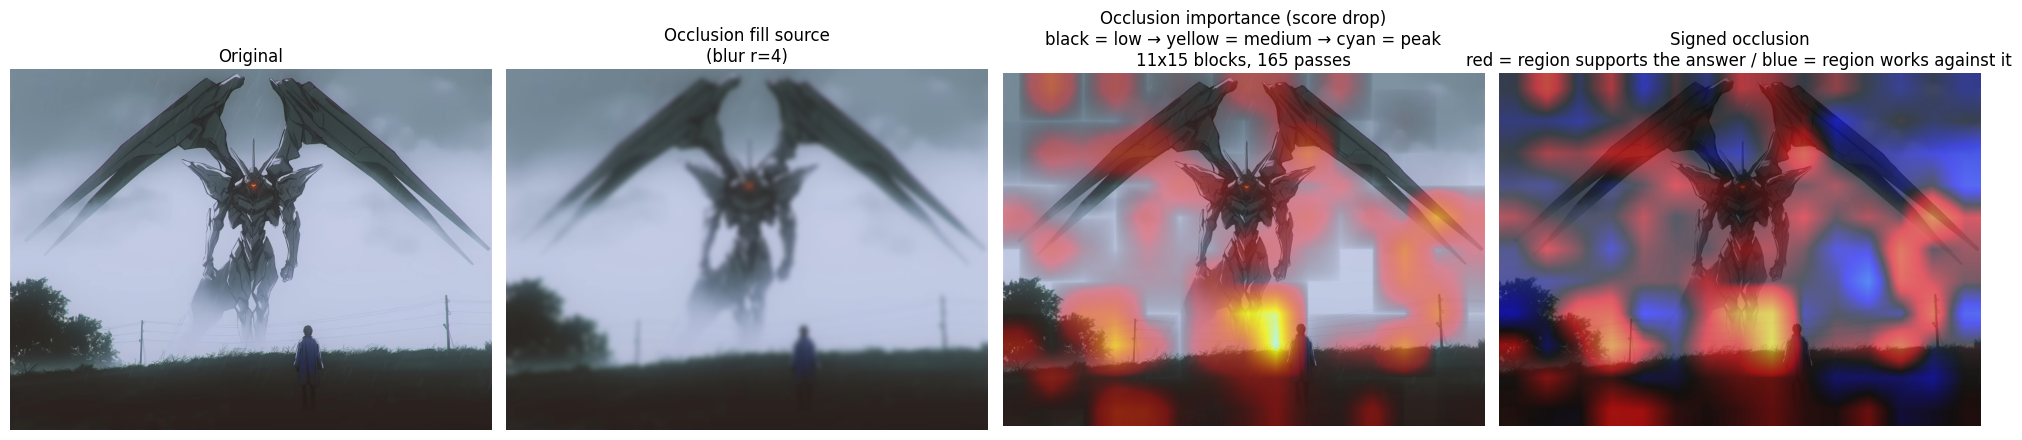


Occlusion grid 11x15 | block 4x4 patches | fill=blur | max drop=3.6049 | min drop=-1.7025


In [11]:
# Step 4 (alt) -> Occlusion-based attribution for Qwen2-VL
# Self-contained: only needs vlm_model, vlm_processor, process_vision_info, base_image
# already defined in earlier setup cells. Does NOT depend on Part A having run.

import torch, torch.nn.functional as F, numpy as np, matplotlib.pyplot as plt
from PIL import ImageFilter
from matplotlib.colors import LinearSegmentedColormap

# =============================================================================================================
# Config
# =============================================================================================================
BLUR_RADIUS      = 4      # baseline blur strength - what an occluded block reveals underneath
OCC_FILL         = "blur" # "blur" -> replace block with blurred-baseline pixels, "gray" -> flat mid-gray
OCC_BLOCK_TOKENS = 2      # occlusion block size in units of MERGED (post-merger) tokens.
                           # 1 = finest possible grid (merged_h x merged_w blocks, slow).
                           # 2-3 = good speed/resolution tradeoff for most images.
MAX_NEW_TOKENS   = 256
PROMPT_TEXT      = "Describe this image and list the main objects you see."

device = next(vlm_model.parameters()).device
vlm_model.eval()
for p in vlm_model.parameters():
    p.requires_grad_(False)

# =============================================================================================================
# Build inputs for the base image (redone here so this cell is independent of Part A)
# =============================================================================================================
messages = [{"role": "user", "content": [{"type": "image", "image": base_image},
                                          {"type": "text", "text": PROMPT_TEXT}]}]
text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = vlm_processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
inputs = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in inputs.items()}

vision = vlm_model.model.visual
grid_t, grid_h, grid_w = [int(x) for x in inputs["image_grid_thw"][0].tolist()]
merge_size = int(vision.spatial_merge_size)
patch_size = vision.patch_embed.patch_size
patch_h, patch_w = (int(patch_size[0]), int(patch_size[1])) if isinstance(patch_size, (tuple, list)) else (int(patch_size),) * 2
processed_width, processed_height = grid_w * patch_w, grid_h * patch_h
merged_h, merged_w = grid_h // merge_size, grid_w // merge_size
channels = 3
extent = [0, processed_width, processed_height, 0]

print(f"Grid: {grid_h}x{grid_w} patches -> {merged_h}x{merged_w} tokens | patch {patch_h}x{patch_w} | merge {merge_size}x{merge_size}")

# =============================================================================================================
# Generate the answer once, then set up teacher-forced scoring (same scoring fn as IG version)
# =============================================================================================================
with torch.no_grad():
    generated_ids = vlm_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

prompt_ids = inputs["input_ids"]
prompt_len = prompt_ids.shape[1]
answer_ids = generated_ids[:, prompt_len:]
answer_text = vlm_processor.tokenizer.decode(answer_ids[0], skip_special_tokens=True)
tokens = vlm_processor.tokenizer.convert_ids_to_tokens(answer_ids[0])
for i, token in enumerate(tokens):
    print(f"{i:3d}: {token!r}")
print("Answer tokens:", answer_ids.shape[1])
print("Answer:", answer_text)

forward_ids = torch.cat([prompt_ids, answer_ids[:, :-1]], dim=1)
forward_inputs = {"input_ids": forward_ids, "attention_mask": torch.ones_like(forward_ids),
                   "pixel_values": inputs["pixel_values"], "image_grid_thw": inputs["image_grid_thw"]}
if "mm_token_type_ids" in inputs:
    answer_types = torch.zeros((1, answer_ids.shape[1] - 1), dtype=inputs["mm_token_type_ids"].dtype, device=device)
    forward_inputs["mm_token_type_ids"] = torch.cat([inputs["mm_token_type_ids"], answer_types], dim=1)

@torch.no_grad()
def answer_score(pixel_values):
    x = forward_inputs.copy()
    x["pixel_values"] = pixel_values.to(next(vlm_model.parameters()).dtype)
    outputs = vlm_model(**x, output_hidden_states=False, return_dict=True, use_cache=False)
    start = prompt_len - 1
    logits = outputs.logits[:, start:start + answer_ids.shape[1], :].float()
    log_probs = F.log_softmax(logits, dim=-1)
    return log_probs.gather(-1, answer_ids.unsqueeze(-1)).squeeze(-1).sum()

# =============================================================================================================
# Baseline (blurred) image, aligned to the same patch grid as the original
# =============================================================================================================
blurred_image = base_image.filter(ImageFilter.GaussianBlur(radius=BLUR_RADIUS))
blur_messages = [{"role": "user", "content": [{"type": "image", "image": blurred_image},
                                               {"type": "text", "text": PROMPT_TEXT}]}]
blur_text = vlm_processor.apply_chat_template(blur_messages, tokenize=False, add_generation_prompt=True)
blur_image_inputs, blur_video_inputs = process_vision_info(blur_messages)
blur_inputs = vlm_processor(text=[blur_text], images=blur_image_inputs, videos=blur_video_inputs, padding=True, return_tensors="pt")
blur_inputs = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in blur_inputs.items()}

pixels = inputs["pixel_values"].detach().float()
baseline = blur_inputs["pixel_values"].detach().float()
# guard: blurred image must produce the same patch grid/token layout as the original
assert pixels.shape == baseline.shape, (pixels.shape, baseline.shape)
assert torch.equal(inputs["image_grid_thw"], blur_inputs["image_grid_thw"])

temporal_patch_size = pixels.shape[1] // (channels * patch_h * patch_w)

def to_grid(flat):
    # (num_patches, patch_dim) -> (grid_h, grid_w, C, T, ph, pw)
    return flat.reshape(grid_t, grid_h, grid_w, channels, temporal_patch_size, patch_h, patch_w)[0]

pixels_grid = to_grid(pixels)
baseline_grid = to_grid(baseline)
gray_value = pixels.mean()

input_score = answer_score(pixels).item()
baseline_score = answer_score(baseline).item()
print(f"Input score: {input_score:.4f} | Full-blur baseline score: {baseline_score:.4f} | Delta: {input_score - baseline_score:.4f}")

# =============================================================================================================
# Occlusion sweep -> slide a block over the image, replace it with baseline content, measure score drop
# =============================================================================================================
block = OCC_BLOCK_TOKENS * merge_size          # occlusion block size in raw patches
occ_rows = int(np.ceil(grid_h / block))
occ_cols = int(np.ceil(grid_w / block))
n_passes = occ_rows * occ_cols
print(f"Occlusion grid: {occ_rows}x{occ_cols} blocks | block size {block}x{block} patches "
      f"({block*patch_h}x{block*patch_w} px) | total forward passes: {n_passes}")

drop_map = np.zeros((occ_rows, occ_cols), dtype=np.float32)  # positive = occluding hurt the score (region matters)

for r in range(occ_rows):
    r0, r1 = r * block, min((r + 1) * block, grid_h)
    for c in range(occ_cols):
        c0, c1 = c * block, min((c + 1) * block, grid_w)
        occluded_grid = pixels_grid.clone()
        if OCC_FILL == "blur":
            occluded_grid[r0:r1, c0:c1] = baseline_grid[r0:r1, c0:c1]
        else:  # "gray"
            occluded_grid[r0:r1, c0:c1] = gray_value
        occluded_flat = occluded_grid.reshape(grid_h * grid_w, channels * temporal_patch_size * patch_h * patch_w)
        score = answer_score(occluded_flat).item()
        drop_map[r, c] = input_score - score
    print(f"  row {r+1:2d}/{occ_rows} done | running max drop so far = {drop_map[:r+1].max():.4f}")

print(f"\nMax drop: {drop_map.max():.4f} | Min drop: {drop_map.min():.4f} | Mean drop: {drop_map.mean():.4f}")
print("(positive = removing this region hurt the answer -> region was important)")
print("(negative = removing this region helped the answer -> region was actively working against it)")

# =============================================================================================================
# Visualize
# =============================================================================================================
def upsample(grid_arr):
    t = torch.tensor(grid_arr, dtype=torch.float32)[None, None]
    return F.interpolate(t, size=(processed_height, processed_width), mode="bilinear", align_corners=False)[0, 0].numpy()

drop_pos = np.clip(drop_map, 0, None)
drop_pos_norm = drop_pos / (drop_pos.max() + 1e-8)
drop_signed_norm = drop_map / (np.abs(drop_map).max() + 1e-8)

drop_pos_up = upsample(drop_pos_norm)
drop_signed_up = upsample(drop_signed_norm)

qwen_image = base_image.resize((processed_width, processed_height))

abs_cmap = LinearSegmentedColormap.from_list("abs_occ",
    [(0.00, "black"), (0.10, "red"), (0.80, "yellow"), (1.00, "#b4ffff")])
signed_cmap = LinearSegmentedColormap.from_list("signed_occ",
    [(0.00, "cyan"), (0.40, "blue"), (0.50, "black"), (0.60, "red"), (1.00, "yellow")])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(base_image); axes[0].set_title("Original"); axes[0].axis("off")
fill_label = f"Occlusion fill source\n(blur r={BLUR_RADIUS})" if OCC_FILL == "blur" else "Occlusion fill source\n(flat gray)"
axes[1].imshow(blurred_image if OCC_FILL == "blur" else np.full((10, 10), float(gray_value)), cmap="gray" if OCC_FILL != "blur" else None)
axes[1].set_title(fill_label); axes[1].axis("off")

alpha = 0.85 * (drop_pos_up ** 0.4)
abs_rgba = abs_cmap(drop_pos_up)
abs_rgba[..., 3] = alpha
axes[2].imshow(qwen_image)
axes[2].imshow(abs_rgba)
axes[2].set_title(f"Occlusion importance (score drop)\nblack = low → yellow = medium → cyan = peak\n{occ_rows}x{occ_cols} blocks, {n_passes} passes")
axes[2].axis("off")

axes[3].imshow(qwen_image)
axes[3].imshow(drop_signed_up, cmap=signed_cmap, alpha=0.55, vmin=-1, vmax=1)
axes[3].set_title("Signed occlusion\nred = region supports the answer / blue = region works against it")
axes[3].axis("off")

plt.tight_layout(); plt.show()

print(f"\nOcclusion grid {occ_rows}x{occ_cols} | block {block}x{block} patches | fill={OCC_FILL} | "
      f"max drop={drop_map.max():.4f} | min drop={drop_map.min():.4f}")

Grid: 44x60 patches -> 22x30 merged tokens | patch 14x14 | merge 2x2

=== Generated answer ===
The image depicts a dramatic scene featuring a large, mechanical figure with wings and a glowing red eye, standing in a misty, overcast landscape. The figure appears to be a futuristic, possibly robotic entity with a sleek, metallic design. The figure is positioned on the left side of the image, with its wings spread wide and its body facing the viewer.

In the foreground, there is a person standing on a grassy field, facing the mechanical figure. The person is dressed in a long, flowing coat, and their posture suggests a sense of awe or contemplation. The field is surrounded by a fence, and in the background, there are trees and a cloudy sky, adding to the somber and intense atmosphere of the scene.

The overall mood of the image is one of suspense and wonder, as the mechanical figure looms over the person, creating a sense of impending danger or revelation.

Answer tokens: 181


=== Matched

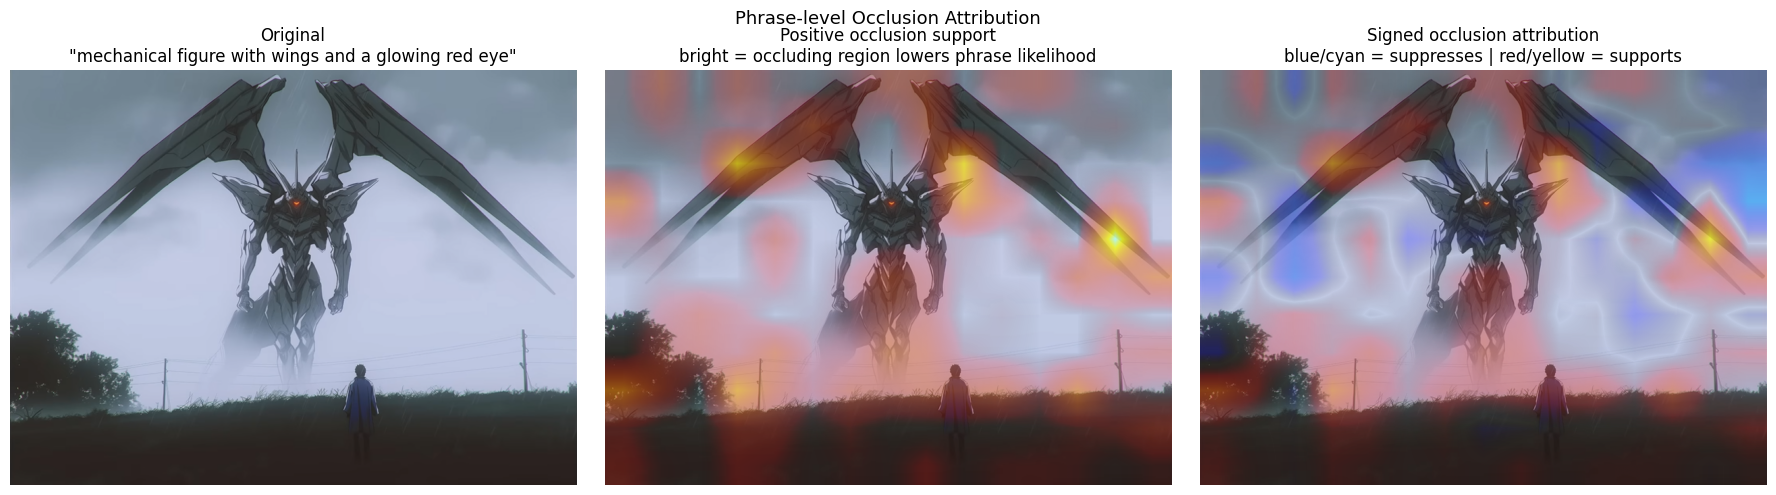

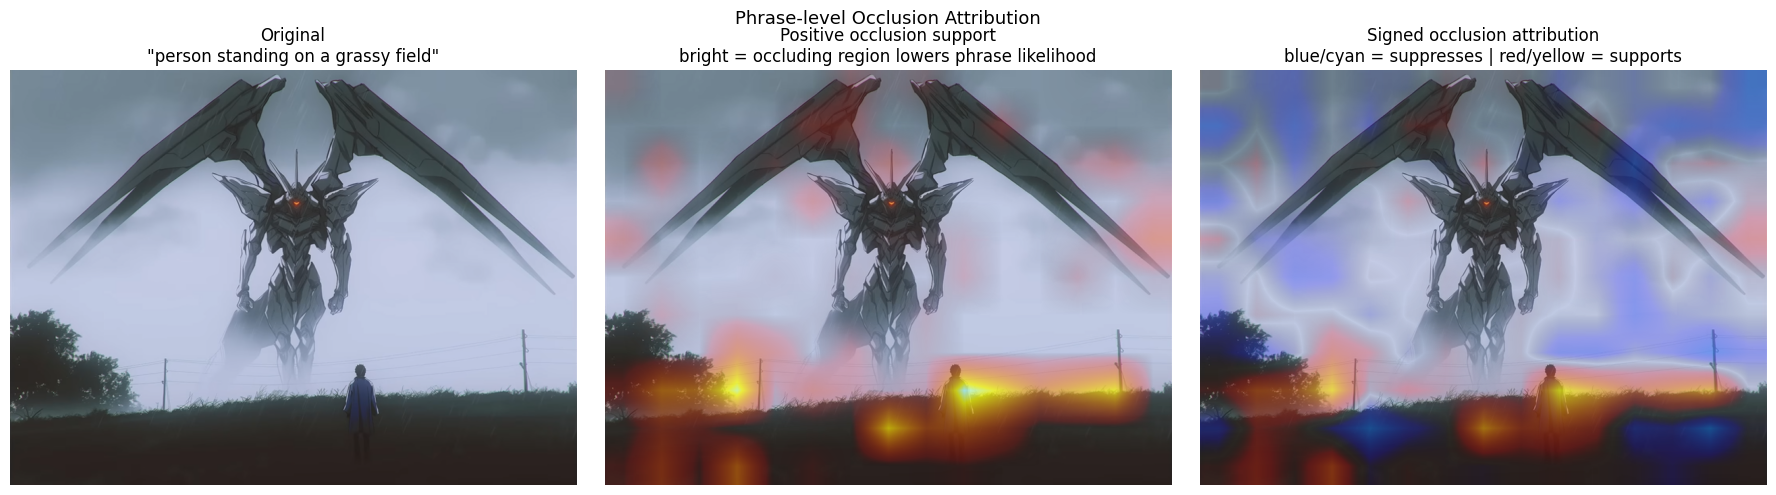


FINAL OCCLUSION SUMMARY

Phrase: mechanical figure with wings and a glowing red eye
  Input score:    -7.6284
  Baseline score: -6.8382
  Input-baseline: -0.7902
  Max support:    0.7682
  Min support:    -0.5174
  Mean support:   0.0527

Phrase: person standing on a grassy field
  Input score:    -2.6420
  Baseline score: -3.5501
  Input-baseline: 0.9081
  Max support:    0.4272
  Min support:    -0.2452
  Mean support:   -0.0031

Interpretation:
  Positive = occluding the region decreased likelihood of the target phrase.
  Negative = occluding the region increased likelihood of the target phrase.
  Zero     = little change in target-phrase likelihood.

This is visual attribution for the selected phrase.
It is NOT an objective measure of answer quality or safety.


In [7]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageFilter
from matplotlib.colors import LinearSegmentedColormap

# Config
BLUR_RADIUS = 4
OCC_FILL = "blur"  # "blur" or "gray"
OCC_BLOCK_TOKENS = 2
PROMPT_TEXT = "Describe this image and list the main objects you see."
TARGET_PHRASES = [
    "mechanical figure with wings and a glowing red eye",
    "person standing on a grassy field"
]

device = next(vlm_model.parameters()).device
vlm_model.eval()
for p in vlm_model.parameters(): p.requires_grad_(False)

# Build inputs
messages = [{"role": "user", "content": [
    {"type": "image", "image": base_image},
    {"type": "text", "text": PROMPT_TEXT}
]}]
text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = vlm_processor(text=[text], images=image_inputs, videos=video_inputs,
                       padding=True, return_tensors="pt")
inputs = {k: v.to(device) if torch.is_tensor(v) else v for k, v in inputs.items()}

# Vision geometry
vision = vlm_model.model.visual
grid_t, grid_h, grid_w = map(int, inputs["image_grid_thw"][0].tolist())
merge_size = int(vision.spatial_merge_size)
patch_size = vision.patch_embed.patch_size
patch_h, patch_w = map(int, patch_size) if isinstance(patch_size, (tuple, list)) else (int(patch_size),) * 2
processed_width, processed_height = grid_w * patch_w, grid_h * patch_h
merged_h, merged_w = grid_h // merge_size, grid_w // merge_size
channels = 3

print(f"Grid: {grid_h}x{grid_w} patches -> {merged_h}x{merged_w} merged tokens | "
      f"patch {patch_h}x{patch_w} | merge {merge_size}x{merge_size}")

# Generate answer
with torch.no_grad():
    generated_ids = vlm_model.generate(**inputs, max_new_tokens=256)

prompt_ids = inputs["input_ids"]
prompt_len = prompt_ids.shape[1]
answer_ids = generated_ids[:, prompt_len:]
answer_text = vlm_processor.tokenizer.decode(answer_ids[0], skip_special_tokens=True)

print(f"\n=== Generated answer ===\n{answer_text}\n\nAnswer tokens: {answer_ids.shape[1]}")

# Teacher-forced inputs
forward_ids = torch.cat([prompt_ids, answer_ids[:, :-1]], dim=1)
forward_inputs = {
    "input_ids": forward_ids,
    "attention_mask": torch.ones_like(forward_ids),
    "pixel_values": inputs["pixel_values"],
    "image_grid_thw": inputs["image_grid_thw"]
}
if "mm_token_type_ids" in inputs:
    answer_types = torch.zeros((1, answer_ids.shape[1] - 1),
                               dtype=inputs["mm_token_type_ids"].dtype, device=device)
    forward_inputs["mm_token_type_ids"] = torch.cat([inputs["mm_token_type_ids"], answer_types], dim=1)

# Blurred baseline
blurred_image = base_image.filter(ImageFilter.GaussianBlur(radius=BLUR_RADIUS))
blur_messages = [{"role": "user", "content": [
    {"type": "image", "image": blurred_image},
    {"type": "text", "text": PROMPT_TEXT}
]}]
blur_text = vlm_processor.apply_chat_template(blur_messages, tokenize=False, add_generation_prompt=True)
blur_image_inputs, blur_video_inputs = process_vision_info(blur_messages)
blur_inputs = vlm_processor(text=[blur_text], images=blur_image_inputs, videos=blur_video_inputs,
                            padding=True, return_tensors="pt")
blur_inputs = {k: v.to(device) if torch.is_tensor(v) else v for k, v in blur_inputs.items()}

# Convert pixel tensors to patch grids
pixels = inputs["pixel_values"].detach().float()
baseline = blur_inputs["pixel_values"].detach().float()
assert pixels.shape == baseline.shape, f"Pixel shape mismatch: {pixels.shape} vs {baseline.shape}"
assert torch.equal(inputs["image_grid_thw"], blur_inputs["image_grid_thw"]), \
    "Original and blurred image have different vision grids."

temporal_patch_size = pixels.shape[1] // (channels * patch_h * patch_w)

def to_grid(flat):
    return flat.reshape(grid_t, grid_h, grid_w, channels, temporal_patch_size, patch_h, patch_w)[0]

pixels_grid, baseline_grid = to_grid(pixels), to_grid(baseline)
gray_value = pixels.mean()

# Tokenize answer and find target phrases
tokenizer = vlm_processor.tokenizer
tok = tokenizer(answer_text, add_special_tokens=False, return_offsets_mapping=True)
offsets = tok["offset_mapping"]
retok_ids = torch.tensor(tok["input_ids"], device=device)

if not torch.equal(retok_ids, answer_ids[0]):
    print("\nWARNING: Re-tokenized answer IDs differ from generated answer IDs. "
          "Phrase matching may be approximate.")

def find_token_span(phrase):
    start = answer_text.lower().find(phrase.lower())
    if start < 0: return None
    end = start + len(phrase)
    ids = [i for i, (s, e) in enumerate(offsets) if e > start and s < end]
    return (ids[0], ids[-1] + 1) if ids else None

phrase_spans = {p: span for p in TARGET_PHRASES if (span := find_token_span(p)) is not None}

for phrase in TARGET_PHRASES:
    if phrase not in phrase_spans:
        print(f"\nWARNING: phrase not found, skipping:\n  {phrase!r}")

if not phrase_spans:
    raise ValueError("No TARGET_PHRASES were found in answer_text. Copy exact substrings from the generated answer.")

print("\n=== Matched phrases ===")
for phrase, span in phrase_spans.items():
    print(f"  {phrase!r} -> tokens {span[0]}:{span[1]}")

# Phrase score
@torch.no_grad()
def span_score(pixel_values, start_token, end_token):
    x = forward_inputs.copy()
    x["pixel_values"] = pixel_values.to(next(vlm_model.parameters()).dtype)
    outputs = vlm_model(**x, output_hidden_states=False, return_dict=True, use_cache=False)
    logits = outputs.logits[:, prompt_len - 1:prompt_len - 1 + answer_ids.shape[1], :].float()
    token_log_probs = F.log_softmax(logits, dim=-1).gather(-1, answer_ids.unsqueeze(-1)).squeeze(-1)
    return token_log_probs[:, start_token:end_token].sum()

# Occlusion geometry
block = OCC_BLOCK_TOKENS * merge_size
occ_rows, occ_cols = int(np.ceil(grid_h / block)), int(np.ceil(grid_w / block))
n_passes = occ_rows * occ_cols

print(f"\n=== Occlusion configuration ===\nGrid: {occ_rows}x{occ_cols} blocks\n"
      f"Block: {block}x{block} raw patches\nApprox pixels/block: {block * patch_h}x{block * patch_w}\n"
      f"Total forward passes per phrase: {n_passes}\nFill: {OCC_FILL}")

def run_phrase_occlusion(start_token, end_token):
    input_score = span_score(pixels, start_token, end_token).item()
    baseline_score = span_score(baseline, start_token, end_token).item()
    support_map = np.zeros((occ_rows, occ_cols), dtype=np.float32)

    for r in range(occ_rows):
        r0, r1 = r * block, min((r + 1) * block, grid_h)
        for c in range(occ_cols):
            c0, c1 = c * block, min((c + 1) * block, grid_w)
            occluded_grid = pixels_grid.clone()

            if OCC_FILL == "blur":
                occluded_grid[r0:r1, c0:c1] = baseline_grid[r0:r1, c0:c1]
            elif OCC_FILL == "gray":
                occluded_grid[r0:r1, c0:c1] = gray_value
            else:
                raise ValueError("OCC_FILL must be 'blur' or 'gray'")

            occluded_flat = occluded_grid.reshape(
                grid_h * grid_w, channels * temporal_patch_size * patch_h * patch_w
            )
            support_map[r, c] = input_score - span_score(
                occluded_flat, start_token, end_token
            ).item()

        print(f"  row {r + 1:2d}/{occ_rows} done | "
              f"max={support_map[:r + 1].max():.4f} | "
              f"min={support_map[:r + 1].min():.4f}")

    return input_score, baseline_score, input_score - baseline_score, support_map

# Map utilities
def upsample(x):
    x = torch.tensor(x, dtype=torch.float32)[None, None]
    return F.interpolate(x, size=(processed_height, processed_width),
                         mode="bilinear", align_corners=False)[0, 0].numpy()

def normalize_signed(x):
    scale = np.max(np.abs(x))
    return np.zeros_like(x) if scale < 1e-8 else x / scale

def normalize_positive(x):
    scale = np.max(x)
    return np.zeros_like(x) if scale < 1e-8 else x / scale

# Colormaps
abs_cmap = LinearSegmentedColormap.from_list(
    "occ_absolute", [(0.00, "black"), (0.10, "red"), (0.80, "yellow"), (1.00, "#b4ffff")]
)
signed_cmap = LinearSegmentedColormap.from_list(
    "occ_signed", [(0.00, "cyan"), (0.40, "blue"), (0.50, "black"), (0.60, "red"), (1.00, "yellow")]
)

# Run all phrases
phrase_results = {}

for phrase, (start_token, end_token) in phrase_spans.items():
    print(f"\n{'=' * 90}\nPhrase: {phrase}\nTokens: {start_token}:{end_token}\n{'=' * 90}")

    input_score, baseline_score, baseline_delta, support_map = run_phrase_occlusion(start_token, end_token)
    positive_map = np.clip(support_map, 0, None)

    result = {
        "support_map": support_map,
        "positive_map": normalize_positive(positive_map),
        "signed_map": normalize_signed(support_map),
        "input_score": input_score,
        "baseline_score": baseline_score,
        "baseline_delta": baseline_delta
    }
    result["positive_up"] = upsample(result["positive_map"])
    result["signed_up"] = upsample(result["signed_map"])
    phrase_results[phrase] = result

    print(f"\nInput phrase score:    {input_score:.4f}"
          f"\nBlur baseline score:   {baseline_score:.4f}"
          f"\nInput - baseline:      {baseline_delta:.4f}"
          f"\nMax regional support:  {support_map.max():.4f}"
          f"\nMin regional support:  {support_map.min():.4f}"
          f"\nMean regional support: {support_map.mean():.4f}")

# Visualization
qwen_image = base_image.resize((processed_width, processed_height))

for phrase, result in phrase_results.items():
    positive_up, signed_up = result["positive_up"], result["signed_up"]

    abs_rgba = abs_cmap(positive_up)
    abs_rgba[..., 3] = 0.85 * np.power(positive_up, 0.7)

    signed_rgba = signed_cmap((signed_up + 1) / 2)
    signed_rgba[..., 3] = 0.70 * np.power(np.abs(signed_up), 0.7)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(qwen_image)
    axes[0].set_title(f'Original\n"{phrase}"')
    axes[0].axis("off")

    axes[1].imshow(qwen_image)
    axes[1].imshow(abs_rgba)
    axes[1].set_title("Positive occlusion support\nbright = occluding region lowers phrase likelihood")
    axes[1].axis("off")

    axes[2].imshow(qwen_image)
    axes[2].imshow(signed_rgba)
    axes[2].set_title("Signed occlusion attribution\nblue/cyan = suppresses | red/yellow = supports")
    axes[2].axis("off")

    plt.suptitle(
        f'Phrase-level Occlusion Attribution\n',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

# Final summary
print("\n" + "=" * 90 + "\nFINAL OCCLUSION SUMMARY\n" + "=" * 90)

for phrase, result in phrase_results.items():
    s = result["support_map"]
    print(f"\nPhrase: {phrase}"
          f"\n  Input score:    {result['input_score']:.4f}"
          f"\n  Baseline score: {result['baseline_score']:.4f}"
          f"\n  Input-baseline: {result['baseline_delta']:.4f}"
          f"\n  Max support:    {s.max():.4f}"
          f"\n  Min support:    {s.min():.4f}"
          f"\n  Mean support:   {s.mean():.4f}")

print("\nInterpretation:"
      "\n  Positive = occluding the region decreased likelihood of the target phrase."
      "\n  Negative = occluding the region increased likelihood of the target phrase."
      "\n  Zero     = little change in target-phrase likelihood."
      "\n\nThis is visual attribution for the selected phrase."
      "\nIt is NOT an objective measure of answer quality or safety.")
